In [15]:
import pandas as pd
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt

In [3]:
diabetes = load_diabetes(as_frame=True)

diabetes_df = diabetes.frame.copy()
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
diabetes_df.shape

(442, 11)

In [8]:
diabetes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [13]:
feature_names = diabetes.feature_names
X = np.asarray(diabetes.data)
# 1. Check if it is mean-centered (Mean should be 0)
means = np.mean(X, axis=0)

# 2. Check the L2 Norm / Unit Length (Should be 1.0)
l2_norms = np.linalg.norm(X, axis=0)

# 3. Check the Sum of Squares (Should be 1.0)
sum_of_squares = np.sum(X**2, axis=0)

print(f"{'Feature':<10} | {'Mean':<20} | {'L2 Norm':<10} | {'Sum of Squares'}")
print("-" * 65)

for i, name in enumerate(feature_names):
    print(f"{name:<10} | {means[i]:<20.4e} | {l2_norms[i]:<10.4f} | {sum_of_squares[i]:.4f}")

Feature    | Mean                 | L2 Norm    | Sum of Squares
-----------------------------------------------------------------
age        | -1.4443e-18          | 1.0000     | 1.0000
sex        | 2.5432e-18           | 1.0000     | 1.0000
bmi        | -2.2559e-16          | 1.0000     | 1.0000
bp         | -4.8541e-17          | 1.0000     | 1.0000
s1         | -1.4286e-17          | 1.0000     | 1.0000
s2         | 3.8988e-17           | 1.0000     | 1.0000
s3         | -6.0284e-18          | 1.0000     | 1.0000
s4         | -1.7881e-17          | 1.0000     | 1.0000
s5         | 9.1681e-17           | 1.0000     | 1.0000
s6         | 1.3518e-17           | 1.0000     | 1.0000


In [14]:
missing_by_column = diabetes_df.isna().sum().sort_values(ascending=False)
missing_by_row = diabetes_df.isna().sum(axis=1)

display(missing_by_column.to_frame("missing_count"))
display((missing_by_column / len(diabetes_df)).to_frame("missing_fraction"))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))
print("Rows with more than one missing value:", int((missing_by_row > 1).sum()))

,missing_count
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


,missing_fraction
age,0.0
sex,0.0
bmi,0.0
bp,0.0
s1,0.0
s2,0.0
s3,0.0
s4,0.0
s5,0.0
s6,0.0


Rows with at least one missing value: 0
Rows with more than one missing value: 0


### 3.2 Descriptive analysis

In [19]:
diabetes_df["target"].describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

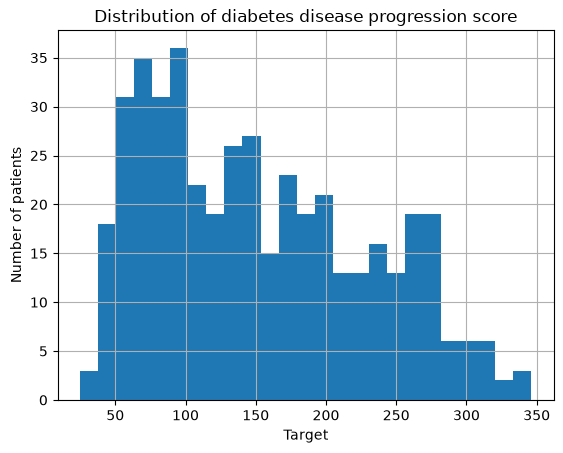

In [16]:
diabetes_df["target"].hist(bins=25)
plt.xlabel("Target")
plt.ylabel("Number of patients")
plt.title("Distribution of diabetes disease progression score")
plt.show()

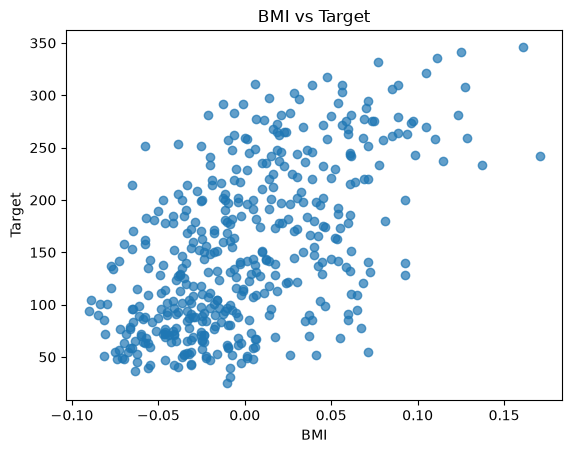

In [21]:
plot_df = diabetes_df.dropna(subset=["target", "bmi"])

plt.scatter(plot_df["bmi"], plot_df["target"], alpha=0.7)
plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("BMI vs Target")
plt.show()

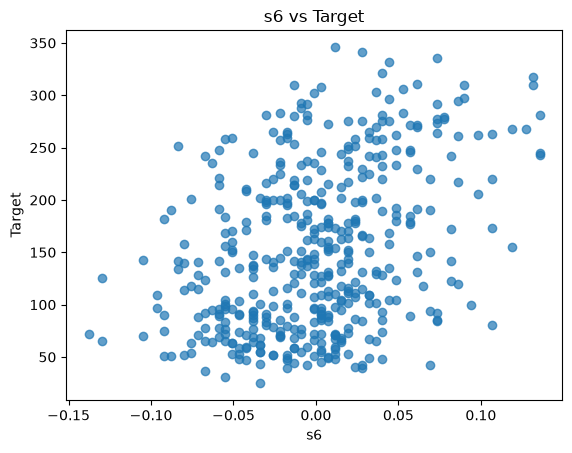

In [22]:
plot_df = diabetes_df.dropna(subset=["target", "s6"])

plt.scatter(plot_df["s6"], plot_df["target"], alpha=0.7)
plt.xlabel("s6")
plt.ylabel("Target")
plt.title("s6 vs Target")
plt.show()

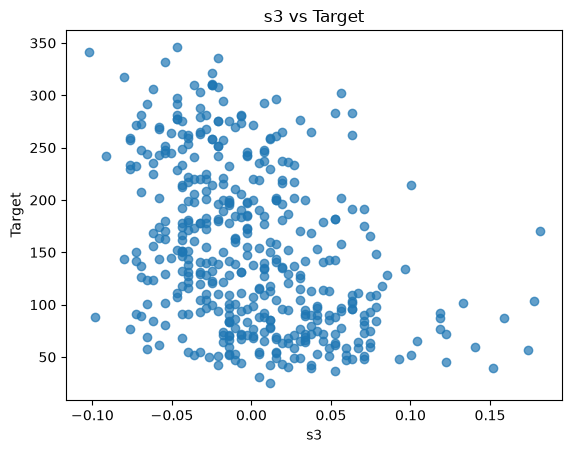

In [23]:
plot_df = diabetes_df.dropna(subset=["target", "s3"])

plt.scatter(plot_df["s3"], plot_df["target"], alpha=0.7)
plt.xlabel("s3")
plt.ylabel("Target")
plt.title("s3 vs Target")
plt.show()

In [17]:
print("Exact duplicate rows", int(diabetes_df.duplicated().sum()))

Exact duplicate rows 0


In [18]:
diabetes_df['sex'].value_counts()

sex
-0.044642    235
 0.050680    207
Name: count, dtype: int64